# 🔬 BioSLATE Phase 3 — Network & Pathway Analysis of Synthetic Lethal Targets

**Author:** Faith Ogundimu  
**Date:** August 2025 

__Notebook Purpose__  
To evaluate protein–protein interactions (PPIs) and biological pathway enrichment for potent synthetic lethal targets identified in Phase 3.  
This integrative analysis helps prioritise gene pairs that are functionally or physically connected, and assesses the broader biological relevance of hits.

__Inputs__  
- Potent SL hit pairs with HGNC symbols (from Phase 3)
- STRING v12.0 PPI data:  
  - `9606.protein.links.detailed.v12.0.txt`  
  - `9606.protein.info.v12.0.txt`
- HGNC symbol ↔ STRING protein ID mappings
- Optional: g:Profiler input gene sets

__Outputs__  
- Direct STRING PPI interactions (combined score ≥ 400) between SL gene pairs  
- CSV summary of which pairs have STRING-supported interactions  
- Pathway enrichment results (Reactome, KEGG, GO) via g:Profiler  
- CSV of enriched pathways for all SL genes or PPI-confirmed subset

__Analysis Summary__  
1. Check whether any biomarker–target pairs directly interact in STRING (high-confidence PPI).
2. Quantify interaction frequency to assess mechanistic plausibility of SL pairs.
3. Run g:Profiler to determine whether SL genes (or PPI-supported subset) are enriched in specific biological pathways.

### Step 1: Check Direct Interactions with STRING

In [1]:
import pandas as pd

# === Parameters ===
STRING_THRESHOLDS = [100, 400, 700]  # Confidence cut-offs to test
PRIMARY_THRESHOLD = 400              # This is the one you actually use for the paper

# Load your data
hits = pd.read_csv('../results/overlapping_amp_unified_hits_with_HGNC.csv')

# Load STRING interaction table
string = pd.read_csv('../database_files/STRING/9606.protein.links.detailed.v12.0.txt', sep=' ')
string['protein1'] = string['protein1'].str.replace('9606.', '', regex=False)
string['protein2'] = string['protein2'].str.replace('9606.', '', regex=False)

# Load STRING protein → gene symbol mapping
info = pd.read_csv('../database_files/STRING/9606.protein.info.v12.0.txt', sep='\t')
info['#string_protein_id'] = info['#string_protein_id'].str.replace('9606.', '', regex=False)

# Build gene ↔ protein ID dictionary
symbol_to_protein = dict(zip(info['preferred_name'], info['#string_protein_id']))

# Filter out hits without STRING mapping
hits = hits[
    hits['Biomarker_AMP_HGNC'].isin(symbol_to_protein) & 
    hits['TargetGene_AMP_HGNC'].isin(symbol_to_protein)
].copy()

# Map genes to STRING protein IDs
hits['protein1'] = hits['Biomarker_AMP_HGNC'].map(symbol_to_protein)
hits['protein2'] = hits['TargetGene_AMP_HGNC'].map(symbol_to_protein)

# Make both orderings to account for STRING's undirected edges
hits['pair1'] = hits['protein1'] + '_' + hits['protein2']
hits['pair2'] = hits['protein2'] + '_' + hits['protein1']

# Make STRING pair index
string['pair'] = string['protein1'] + '_' + string['protein2']

# --- Apply primary threshold for actual PPI flag ---
string_primary = string[string['combined_score'] >= PRIMARY_THRESHOLD]
hits['PPI_found'] = hits['pair1'].isin(string_primary['pair']) | hits['pair2'].isin(string_primary['pair'])

# Save the PPI result table
hits[['Biomarker_AMP_HGNC', 'TargetGene_AMP_HGNC', 'PPI_found']].to_csv(
    '../results/unified_validation_cna_expr_fdr_removed/overlapping_hits_STRING_PPI_check.csv', index=False
)

# --- Count PPIs at all thresholds for reporting ---
ppi_counts = {}
for thr in STRING_THRESHOLDS:
    s_thr = string[string['combined_score'] >= thr]
    found = hits['pair1'].isin(s_thr['pair']) | hits['pair2'].isin(s_thr['pair'])
    ppi_counts[thr] = found.sum()

ppi_counts_df = pd.DataFrame({
    'STRING_threshold': list(ppi_counts.keys()),
    'PPI_pairs_found': list(ppi_counts.values())
})
ppi_counts_df.to_csv('../results/unified_validation_cna_expr_fdr_removed/ppi_counts_by_threshold.csv', index=False)

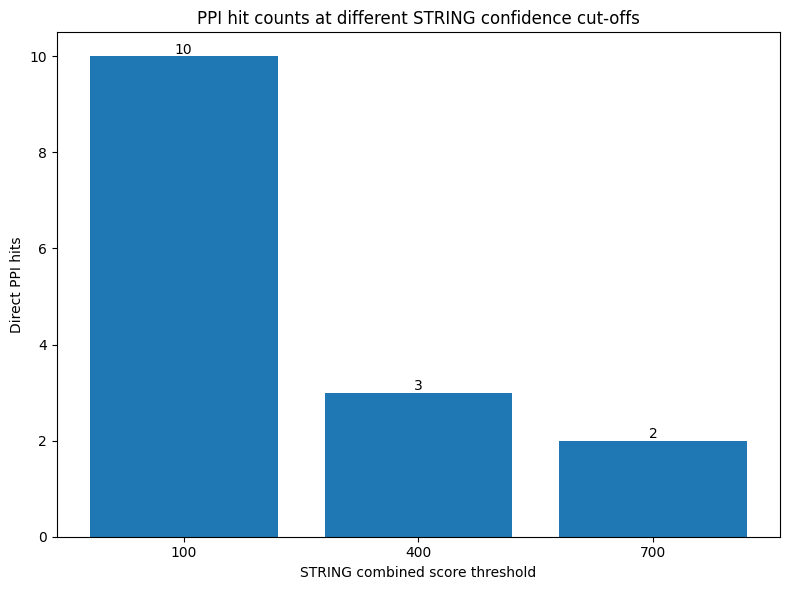

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Load precomputed counts
ppi_counts_df = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/ppi_counts_by_threshold.csv')

# Bar chart
plt.figure(figsize=(8,6))
plt.bar(ppi_counts_df['STRING_threshold'].astype(str), ppi_counts_df['PPI_pairs_found'])
plt.xlabel('STRING combined score threshold')
plt.ylabel('Direct PPI hits')
plt.title('PPI hit counts at different STRING confidence cut-offs')
for i, val in enumerate(ppi_counts_df['PPI_pairs_found']):
    plt.text(i, val + 0.05, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/ppi_hits_bar_chart.png', dpi=300)
plt.show()

### Step 2: Check with g:Profiler

### Run Enrichment Analysis

In [6]:
import sys
import subprocess

# Install the gprofiler-official package if it's not already installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "gprofiler-official"])

# Now import it using the correct module name for v1.0+
from gprofiler import GProfiler


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip3.10 install --upgrade pip


In [4]:
from gprofiler import GProfiler

# Initialise the client
gp = GProfiler(return_dataframe=True)

with open("../results/unified_validation_cna_expr_fdr_removed/gprofiler_biomarkers.txt", "r") as f:
    biomarker_list = [line.strip() for line in f if line.strip()]  # remove empty lines
print(biomarker_list)

with open("../results/unified_validation_cna_expr_fdr_removed/gprofiler_targets.txt", "r") as f:
    targets_list = [line.strip() for line in f if line.strip()]  # remove empty lines
print(targets_list)

# Run enrichment: REACTOME, GO, KEGG, etc., and include actual gene hits
results_biomarkers = gp.profile(
    organism='hsapiens',
    query=biomarker_list,
    sources=['GO:BP', 'REAC', 'KEGG'],
    no_evidences=False
)

results_targets = gp.profile(
    organism='hsapiens',
    query=targets_list,
    sources=['GO:BP', 'REAC', 'KEGG'],
    no_evidences=False
)

# Preview top hits
results_biomarkers.to_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_biomarkers.csv', index=False)
results_targets.to_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_targets.csv', index=False)

['AKT2', 'PIK3CB', 'ASPH', 'ATP6V1C1', 'BICD1', 'LRRC14', 'CCDC91', 'CCNE1', 'CCNL1', 'CDH6', 'CMAS', 'AHCTF1', 'ZC3HC1', 'COX20', 'CTHRC1', 'DERL1', 'DESI2', 'DHX36', 'DNM1L', 'ACTN4', 'EEF1D', 'ERGIC2', 'ETNK1', 'FAM91A1', 'FH', 'GPATCH1', 'IPO8', 'LSM14A', 'TCEA1', 'MFSD3', 'PTDSS1', 'NDUFB9', 'OPA1', 'OXR1', 'MTDH', 'PAK4', 'PLD3', 'PLSCR1', 'PPFIBP1', 'PTK2', 'SCRIB', 'RBM12B', 'RSF1', 'MED29', 'RAP2B', 'SIPA1L3', 'SMC4', 'SMYD3', 'SPINT2', 'STK38L', 'SUPT5H', 'TBL1XR1', 'TIMM50', 'TGS1', 'UBE2H', 'UBN2', 'YWHAZ', 'ATAD2']
['SGO1', 'ZNF875', 'MYBL2', 'AK6', 'SNAP23', 'ESF1', 'CCDC174', 'CCNE1', 'CDK2', 'HAMP', 'LENG8', 'MRPL11', 'MRPS14', 'MTERF3', 'PLEKHF1', 'PRPF39', 'PRR13', 'SKP2', 'ZNF780B', 'PAX8', 'LIN54', 'MAEA', 'UBE2J2', 'YTHDF2', 'POLA1', 'CUL1', 'PARN', 'RRP9', 'LRFN1', 'NOP14', 'VBP1', 'PARD6B', 'KRT8', 'HAPSTR1', 'RAD51D', 'CENPI', 'DDX39B', 'DPRX', 'APLP1', 'HAUS2', 'LGALS4', 'MRPS10', 'POMP', 'TNPO1', 'TWF1', 'PFDN1', 'COA7', 'FAM98C', 'KDM2A', 'MRPS12', 'MRPS21', 

In [5]:
# Directly explode the 'intersections' column

mapping_biomarkers = results_biomarkers[['name', 'intersections']].explode('intersections')
mapping_biomarkers.columns = ['Pathway', 'Gene']

# Save to file
mapping_biomarkers.to_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_biomarkers.csv', index=False)

########

# Directly explode the 'intersections' column

mapping_targets = results_targets[['name', 'intersections']].explode('intersections')
mapping_targets.columns = ['Pathway', 'Gene']

# Save to file
mapping_targets.to_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_targets.csv', index=False)

### Step 3: Visualizations

#### 1. Barplot of Top Pathways (by −log₁₀(p-value))

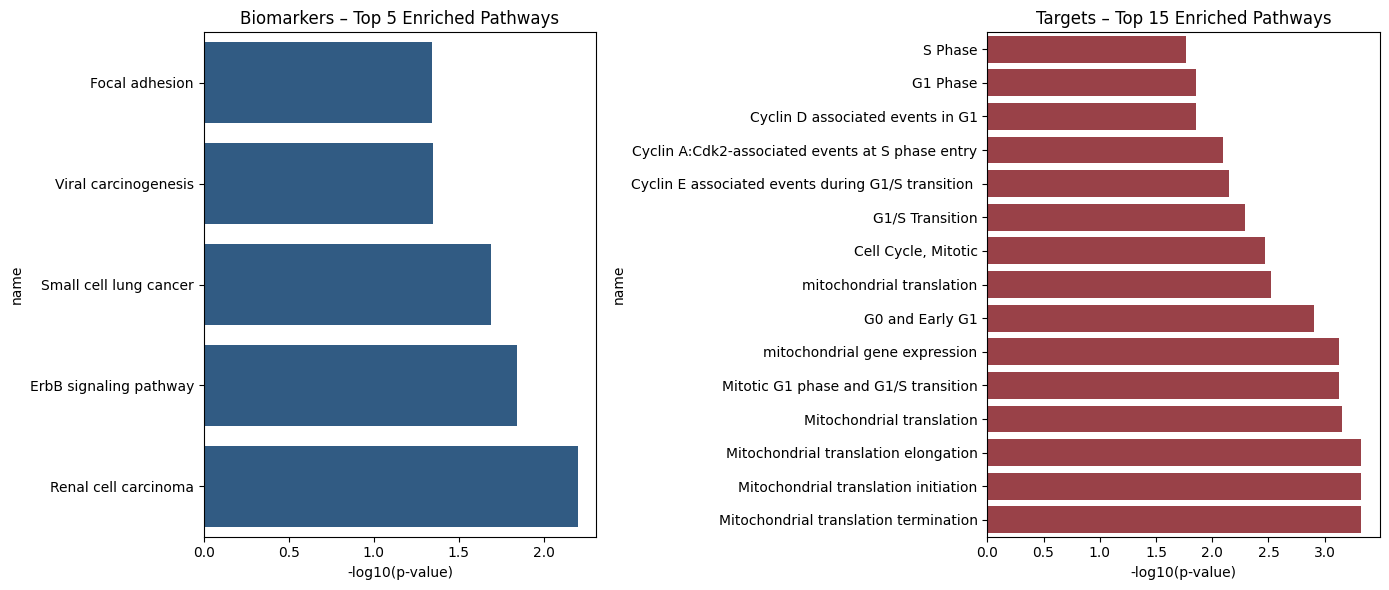

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load biomarker and target enrichment results
bio_df = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_biomarkers.csv')
tar_df = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_targets.csv')

# Filter significant terms
bio_sig = bio_df[bio_df['significant'] == True].copy()
tar_sig = tar_df[tar_df['significant'] == True].copy()

# Get top 15 by p-value for each
bio_top = bio_sig.nsmallest(15, 'p_value')
tar_top = tar_sig.nsmallest(15, 'p_value')

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# Biomarkers plot
sns.barplot(y='name', x=-np.log10(bio_top['p_value']), data=bio_top, color='#235b91', ax=axes[0])
axes[0].set_title('Biomarkers – Top 5 Enriched Pathways')
axes[0].set_xlabel('-log10(p-value)')
axes[0].invert_yaxis()

# Targets plot
sns.barplot(y='name', x=-np.log10(tar_top['p_value']), data=tar_top, color='#a8323c', ax=axes[1])
axes[1].set_title('Targets – Top 15 Enriched Pathways')
axes[1].set_xlabel('-log10(p-value)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Dot Plot (Pathway × Gene matrix as dots)

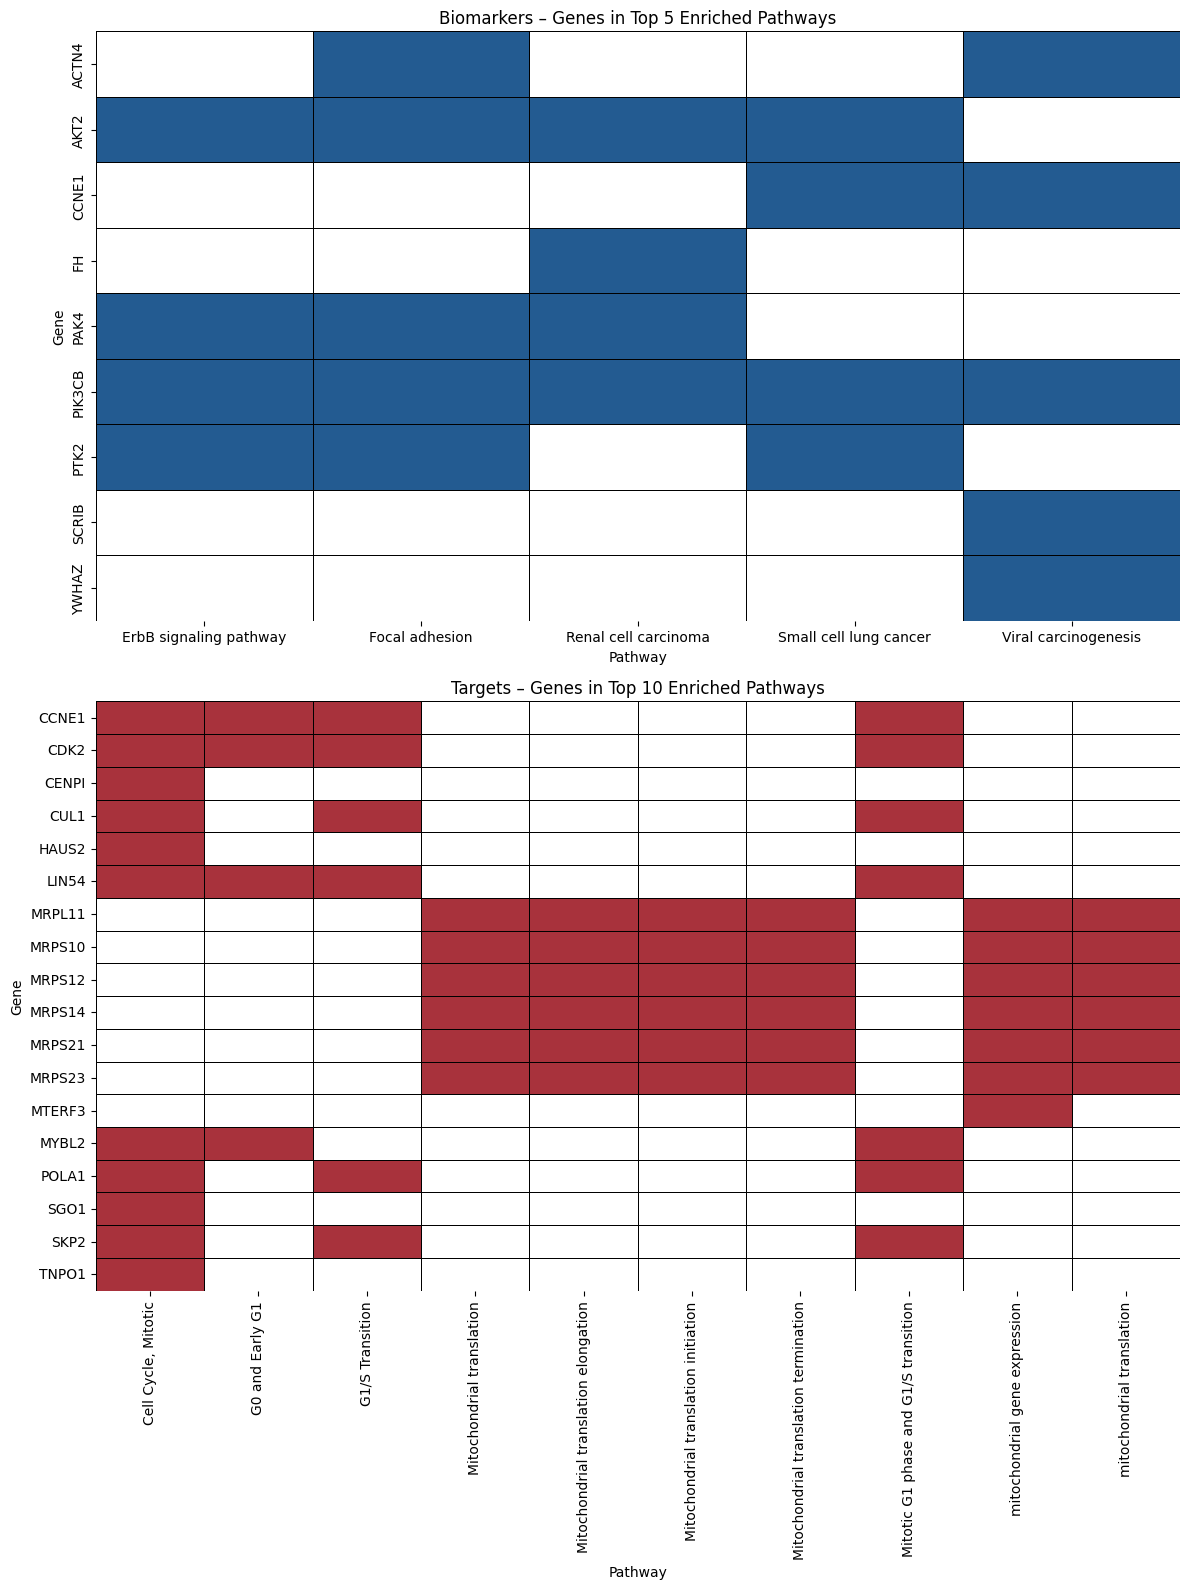

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# --- Load gene-to-pathway mappings ---
bio_map = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_biomarkers.csv')
tar_map = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_targets.csv')

# --- Load enrichment results ---
bio_enrich = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_biomarkers.csv')
tar_enrich = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gprofiler_enrichment_targets.csv')

# Filter significant
bio_sig = bio_enrich[bio_enrich['significant'] == True].copy()
tar_sig = tar_enrich[tar_enrich['significant'] == True].copy()

# --- Top 10 pathways by p-value ---
bio_top_paths = bio_sig.nsmallest(10, 'p_value')['name'].tolist()
tar_top_paths = tar_sig.nsmallest(10, 'p_value')['name'].tolist()

# --- Filter mapping to top pathways ---
bio_filtered = bio_map[bio_map['Pathway'].isin(bio_top_paths)]
tar_filtered = tar_map[tar_map['Pathway'].isin(tar_top_paths)]

# --- Create binary matrices ---
bio_dot = bio_filtered.groupby(['Pathway', 'Gene']).size().unstack(fill_value=0)
tar_dot = tar_filtered.groupby(['Pathway', 'Gene']).size().unstack(fill_value=0)

# --- Colormaps ---
blue_cmap = ListedColormap(["white", "#235b91"])
red_cmap = ListedColormap(["white", "#a8323c"])

# --- Plot two heatmaps stacked ---
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Biomarkers heatmap
sns.heatmap(
    bio_dot.T,
    cmap=blue_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    ax=axes[0]
)
axes[0].set_title("Biomarkers – Genes in Top 5 Enriched Pathways")
axes[0].set_xlabel("Pathway")
axes[0].set_ylabel("Gene")

# Targets heatmap
sns.heatmap(
    tar_dot.T,
    cmap=red_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    ax=axes[1]
)
axes[1].set_title("Targets – Genes in Top 10 Enriched Pathways")
axes[1].set_xlabel("Pathway")
axes[1].set_ylabel("Gene")

plt.tight_layout()
plt.show()

#### Circular Pathway–Gene Network (Hive/Circos-style)

In [2]:
import sys
!{sys.executable} -m pip install holoviews bokeh 

  Using cached holoviews-1.21.0-py3-none-any.whl.metadata (10 kB)
  Using cached bokeh-3.7.3-py3-none-any.whl.metadata (12 kB)
  Using cached colorcet-3.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached panel-1.7.5-py3-none-any.whl.metadata (15 kB)
  Using cached param-2.2.1-py3-none-any.whl.metadata (6.6 kB)
  Using cached pyviz_comms-3.0.6-py3-none-any.whl.metadata (7.7 kB)
  Using cached xyzservices-2025.4.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached linkify_it_py-2.0.3-py3-none-any.whl.metadata (8.5 kB)
  Using cached mdit_py_plugins-0.4.2-py3-none-any.whl.metadata (2.8 kB)
  Using cached uc_micro_py-1.0.3-py3-none-any.whl.metadata (2.0 kB)
Using cached holoviews-1.21.0-py3-none-any.whl (5.9 MB)
Using cached bokeh-3.7.3-py3-none-any.whl (7.0 MB)
Using cached panel-1.7.5-py3-none-any.whl (29.5 MB)
Using cached param-2.2.1-py3-none-any.whl (119 kB)
Using cached pyviz_comms-3.0.6-py3-none-any.whl (84 kB)
Using cached xyzservices-2025.4.0-py3-none-any.whl (90 kB)
Using cache

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
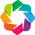

:Chord   [source,target]

In [11]:
import pandas as pd
import holoviews as hv
from holoviews import opts, dim
hv.extension('bokeh')
from holoviews.element.graphs import Chord

# --- Load biomarker gene-to-pathway mapping ---
bio_map = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_biomarkers.csv')

# Collapse redundant pathway terms (customised for these KEGG terms)
collapse_map = {
    'Renal cell carcinoma': 'Renal cell carcinoma',
    'ErbB signaling pathway': 'ErbB signalling',
    'Small cell lung cancer': 'Small cell lung cancer',
    'Viral carcinogenesis': 'Viral carcinogenesis',
    'Focal adhesion': 'Focal adhesion',
}

bio_map['CollapsedPathway'] = bio_map['Pathway'].replace(collapse_map)

# Keep only those collapsed pathways
keep_terms = set(collapse_map.values())
subset = bio_map[bio_map['CollapsedPathway'].isin(keep_terms)]

# OPTIONAL: remove underpowered pathways (<3 genes)
counts = subset['CollapsedPathway'].value_counts()
valid_pathways = counts[counts >= 3].index
subset = subset[subset['CollapsedPathway'].isin(valid_pathways)]

# Build edges
edges = subset[['Gene', 'CollapsedPathway']].drop_duplicates()
edges.columns = ['Gene', 'Pathway']

# Create node list
unique_pathways = edges['Pathway'].unique().tolist()
unique_genes = edges['Gene'].unique().tolist()
nodes_df = pd.DataFrame({'name': unique_pathways + unique_genes})
nodes_df['type'] = ['Pathway'] * len(unique_pathways) + ['Gene'] * len(unique_genes)
nodes_df['index'] = range(len(nodes_df))

# Define colours for each pathway
color_dict = {
    'Renal cell carcinoma': '#1f77b4',
    'ErbB signalling': '#ff7f0e',
    'Small cell lung cancer': '#2ca02c',
    'Viral carcinogenesis': '#d62728',
    'Focal adhesion': '#9467bd',
}

# Prepare Chord edges
edges_named = edges.copy()
edges_named.columns = ['source', 'target']

# Create Chord diagram
chord = Chord((edges_named, hv.Dataset(nodes_df, 'name')))

chord.opts(
    opts.Chord(
        labels='name',
        node_color=dim('name').categorize(color_dict, default='#9edae5'),
        edge_color=dim('target').categorize(color_dict, default='#9edae5'),
        width=950,
        height=950,
        title="Biomarker Genes in Enriched Pathways"
    )
)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
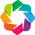

:Chord   [source,target]

In [12]:
import pandas as pd
import holoviews as hv
from holoviews import opts, dim
hv.extension('bokeh')
from holoviews.element.graphs import Chord

# --- Load target gene-to-pathway mapping ---
tar_map = pd.read_csv('../results/unified_validation_cna_expr_fdr_removed/gene_to_pathway_map_targets.csv')

# Collapse redundant pathway terms (customised for these Reactome terms)
collapse_map = {
    'Mitochondrial translation termination': 'Mitochondrial translation',
    'Mitochondrial translation initiation': 'Mitochondrial translation',
    'Mitochondrial translation elongation': 'Mitochondrial translation',
    'Mitochondrial translation': 'Mitochondrial translation',
    'mitochondrial translation': 'Mitochondrial translation',
    'mitochondrial gene expression': 'Mitochondrial gene expression',
    'Cell Cycle, Mitotic': 'Cell cycle',
    'Cell Cycle': 'Cell cycle',
    'cell cycle': 'Cell cycle',
    'G1/S Transition': 'Cell cycle checkpoints',
    'G1 Phase': 'Cell cycle checkpoints',
    'G0 and Early G1': 'Cell cycle checkpoints',
    'S Phase': 'DNA synthesis',
    'chromosome organization': 'Chromosome organization',
    'Mitotic G1 phase and G1/S transition': 'Cell cycle checkpoints',
    'Phosphorylation of proteins involved in G1/S transition by active Cyclin E:Cdk2 complexes': 'Cell cycle checkpoints',
    'Cyclin E associated events during G1/S transition ': 'Cell cycle checkpoints',
    'Cyclin A:Cdk2-associated events at S phase entry': 'DNA synthesis',
    'Cyclin D associated events in G1': 'Cell cycle checkpoints',
    'SCF(Skp2)-mediated degradation of p27/p21': 'Cell cycle checkpoints',
    'Synthesis of DNA': 'DNA synthesis',
    'Ribosome': 'Ribosome',
}

tar_map['CollapsedPathway'] = tar_map['Pathway'].replace(collapse_map)

# Keep only those collapsed pathways
keep_terms = set(collapse_map.values())
subset = tar_map[tar_map['CollapsedPathway'].isin(keep_terms)]

# OPTIONAL: remove underpowered pathways (<3 genes)
counts = subset['CollapsedPathway'].value_counts()
valid_pathways = counts[counts >= 3].index
subset = subset[subset['CollapsedPathway'].isin(valid_pathways)]

# Build edges
edges = subset[['Gene', 'CollapsedPathway']].drop_duplicates()
edges.columns = ['Gene', 'Pathway']

# Create node list
unique_pathways = edges['Pathway'].unique().tolist()
unique_genes = edges['Gene'].unique().tolist()
nodes_df = pd.DataFrame({'name': unique_pathways + unique_genes})
nodes_df['type'] = ['Pathway'] * len(unique_pathways) + ['Gene'] * len(unique_genes)
nodes_df['index'] = range(len(nodes_df))

# Define colours for each pathway
color_dict = {
    'Mitochondrial translation': '#1f77b4',
    'Mitochondrial gene expression': '#aec7e8',
    'Cell cycle': '#2ca02c',
    'Cell cycle checkpoints': '#98df8a',
    'DNA synthesis': '#ff7f0e',
    'Chromosome organization': '#ffbb78',
    'Ribosome': '#9467bd',
}

# Prepare Chord edges
edges_named = edges.copy()
edges_named.columns = ['source', 'target']

# Create Chord diagram
chord = Chord((edges_named, hv.Dataset(nodes_df, 'name')))

chord.opts(
    opts.Chord(
        labels='name',
        node_color=dim('name').categorize(color_dict, default='#9edae5'),
        edge_color=dim('target').categorize(color_dict, default='#9edae5'),
        width=950,
        height=950,
        title="Target Genes in Enriched Pathways"
    )
)